In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from pathlib import Path

plt.style.use('seaborn-v0_8')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (10, 6)

PROJECT_ROOT = Path("/scratch/zt1/project/msml612/user/jeffy22/MSML612_EnergyForecasting")
RESULTS_DIR = PROJECT_ROOT / "results" / "jeffy22"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Results directory: {RESULTS_DIR}")

Results directory: /scratch/zt1/project/msml612/user/jeffy22/MSML612_EnergyForecasting/results/jeffy22


In [2]:
supervised_csv = RESULTS_DIR / "experiment_results.csv"

if supervised_csv.exists():
    df_all = pd.read_csv(supervised_csv)
    df_supervised = df_all[df_all['mse'].notna()].copy()
    print(f"Loaded {len(df_supervised)} supervised runs")
    print("\nExperiments found:")
    print(df_supervised['experiment_name'].value_counts())
    print("\nFirst few rows:")
    df_supervised[['experiment_name', 'run', 'mse', 'mae']].head()
else:
    print("experiment_results.csv not found")
    df_supervised = pd.DataFrame()

Loaded 12 supervised runs

Experiments found:
experiment_name
Baseline_d128_h8_ff256            6
Paper_Hyperparams_d16_h4_ff128    5
Paper_ETTh1_336_96                1
Name: count, dtype: int64

First few rows:


In [3]:
# Find all supervised loss files
loss_files = glob.glob(str(PROJECT_ROOT / "PatchTST/PatchTST_supervised/results/*/losses.csv"))

loss_data = {}
for f in loss_files:
    df = pd.read_csv(f)
    folder = Path(f).parent.name
    
    if 'baseline' in folder.lower():
        name = 'Baseline'
    elif 'paper' in folder.lower():
        name = 'Paper Hyperparams'
    else:
        name = folder
    
    loss_data[name] = df
    print(f"Loaded: {name} - {len(df)} epochs")

print(f"\nTotal loss curves: {len(loss_data)}")

Loaded: Paper Hyperparams - 55 epochs
Loaded: Baseline - 27 epochs
Loaded: Paper Hyperparams - 35 epochs
Loaded: Baseline - 19 epochs
Loaded: Baseline - 22 epochs
Loaded: Paper Hyperparams - 38 epochs
Loaded: Paper Hyperparams - 56 epochs
Loaded: Paper Hyperparams - 35 epochs
Loaded: Baseline - 25 epochs
Loaded: Baseline - 17 epochs

Total loss curves: 2


In [4]:
if len(df_supervised) > 0:
    baseline_df = df_supervised[df_supervised['experiment_name'] == 'Baseline_d128_h8_ff256']
    paper_df = df_supervised[df_supervised['experiment_name'] == 'Paper_Hyperparams_d16_h4_ff128']
    
    baseline_avg = baseline_df['mse'].mean() if len(baseline_df) > 0 else None
    baseline_std = baseline_df['mse'].std() if len(baseline_df) > 0 else None
    baseline_mae_avg = baseline_df['mae'].mean() if len(baseline_df) > 0 else None
    
    paper_avg = paper_df['mse'].mean() if len(paper_df) > 0 else None
    paper_std = paper_df['mse'].std() if len(paper_df) > 0 else None
    paper_mae_avg = paper_df['mae'].mean() if len(paper_df) > 0 else None
    
    print("SUPERVISED RESULTS SUMMARY")
    if baseline_avg:
        print(f"Baseline (d_model=128):")
        print(f"  MSE = {baseline_avg:.4f} ± {baseline_std:.4f}")
        print(f"  MAE = {baseline_mae_avg:.4f}")
    if paper_avg:
        print(f"\nPaper Hyperparams (d_model=16):")
        print(f"  MSE = {paper_avg:.4f} ± {paper_std:.4f}")
        print(f"  MAE = {paper_mae_avg:.4f}")

SUPERVISED RESULTS SUMMARY
Baseline (d_model=128):
  MSE = 0.3673 ± 0.0012
  MAE = 0.3939

Paper Hyperparams (d_model=16):
  MSE = 0.3812 ± 0.0027
  MAE = 0.4057


In [9]:
baseline_val = baseline_avg if baseline_avg else 0
paper_val = paper_avg if paper_avg else 0

results_table = pd.DataFrame([
    {'Model': 'ARIMA', 'MSE': 0.871, 'MAE': 0.711, 'Source': 'Classical'},
    {'Model': 'LSTM', 'MSE': 0.631, 'MAE': 0.583, 'Source': 'RNN'},
    {'Model': 'DLinear', 'MSE': 0.410, 'MAE': 0.282, 'Source': 'Linear'},
    {'Model': 'Our Baseline', 'MSE': baseline_val, 'MAE': baseline_mae_avg if baseline_mae_avg else 0, 'Source': 'Our Implementation'},
    {'Model': 'Our Paper Hyperparams', 'MSE': paper_val, 'MAE': paper_mae_avg if paper_mae_avg else 0, 'Source': 'Our Implementation'},
])

results_table = results_table[results_table['MSE'] > 0]
results_table['MSE'] = results_table['MSE'].round(4)
results_table['MAE'] = results_table['MAE'].round(4)

print("Complete Results Table:")
results_table

Complete Results Table:


,Model,MSE,MAE,Source
0,ARIMA,0.8710,0.7110,Classical
1,LSTM,0.6310,0.5830,RNN
2,DLinear,0.4100,0.2820,Linear
3,Our Baseline,0.3673,0.3939,Our Implementation
4,Our Paper Hyperparams,0.3812,0.4057,Our Implementation


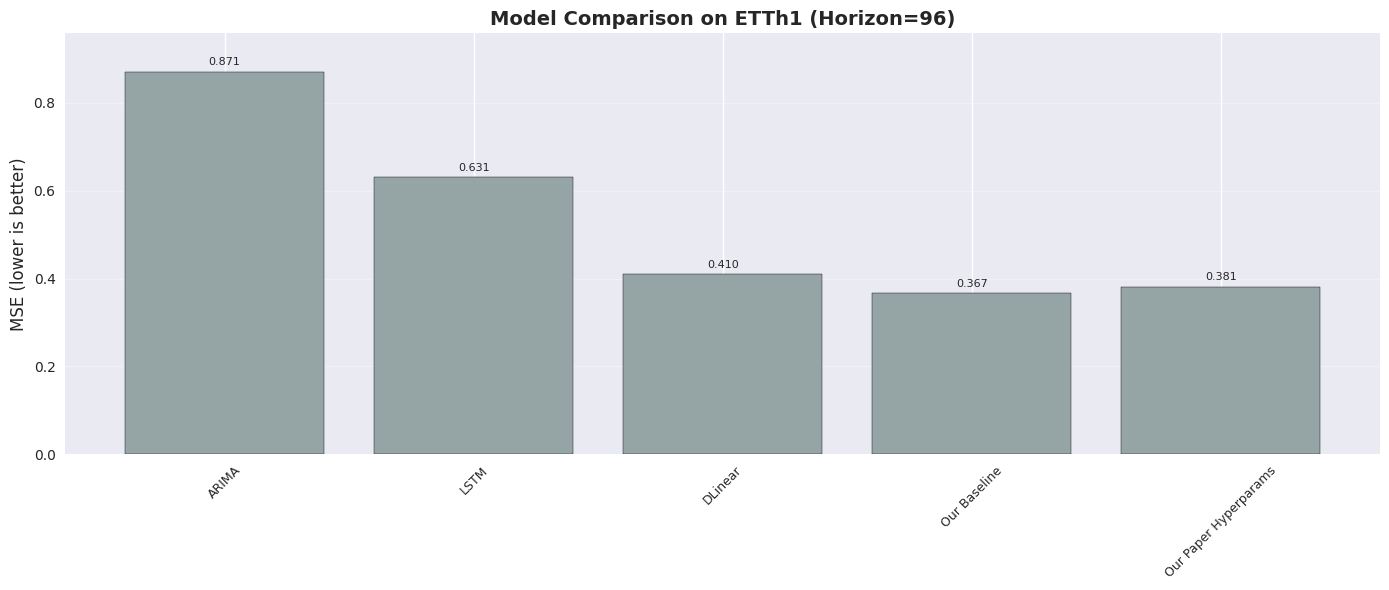

Saved to: /scratch/zt1/project/msml612/user/jeffy22/MSML612_EnergyForecasting/results/jeffy22/supervised_model_comparison.png


In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#95a5a6'] * 7 + ['#2ecc71', '#e74c3c']
bars = ax.bar(results_table['Model'], results_table['MSE'], color=colors[:len(results_table)], edgecolor='black')

ax.set_ylabel('MSE (lower is better)', fontsize=12)
ax.set_title('Model Comparison on ETTh1 (Horizon=96)', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(results_table['MSE']) * 1.1)

for bar, val in zip(bars, results_table['MSE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'supervised_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {RESULTS_DIR / 'supervised_model_comparison.png'}")

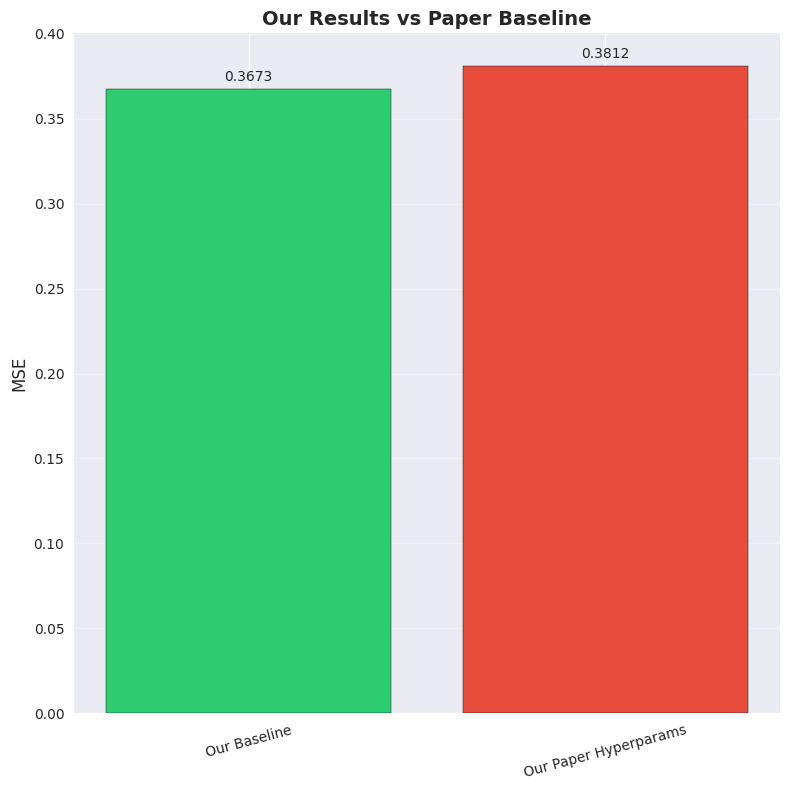

Saved to: /scratch/zt1/project/msml612/user/jeffy22/MSML612_EnergyForecasting/results/jeffy22/supervised_our_results.png


In [10]:
fig, ax = plt.subplots(figsize=(8, 8))

our_results = results_table[results_table['Source'] == 'Our Implementation']
colors = ['#2ecc71', '#e74c3c']
bars = ax.bar(our_results['Model'], our_results['MSE'], color=colors, edgecolor='black')

ax.set_ylabel('MSE', fontsize=12)
ax.set_title('Our Results vs Paper Baseline', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, our_results['MSE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003, 
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'supervised_our_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {RESULTS_DIR / 'supervised_our_results.png'}")

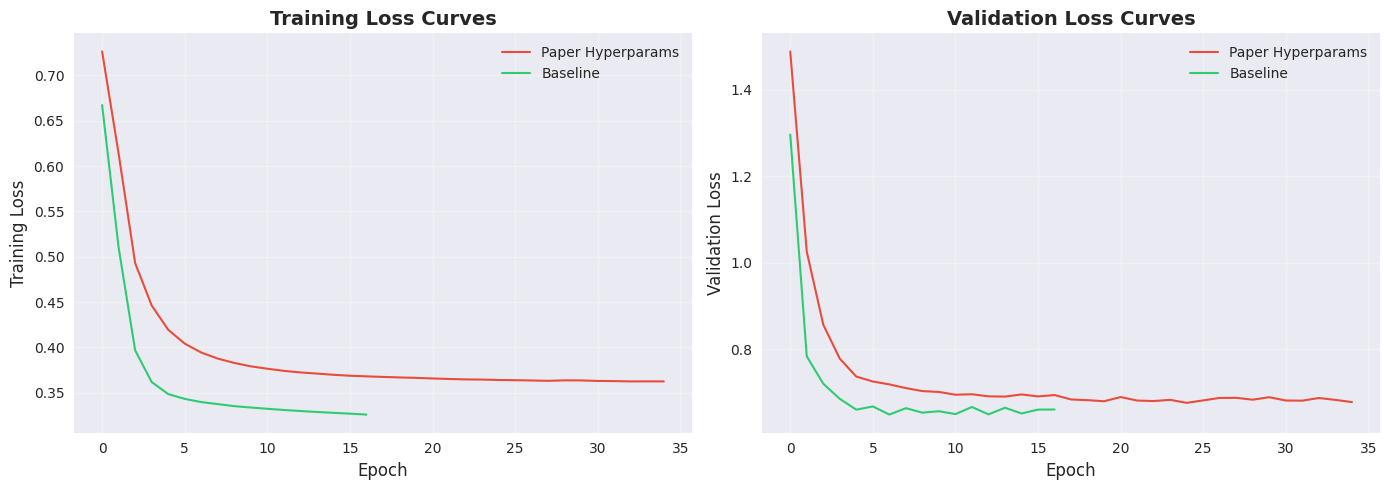

Saved to: /scratch/zt1/project/msml612/user/jeffy22/MSML612_EnergyForecasting/results/jeffy22/supervised_loss_curves.png


In [11]:
if loss_data:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    colors = {'Baseline': '#2ecc71', 'Paper Hyperparams': '#e74c3c'}
    
    for name, df in loss_data.items():
        if 'train_loss' in df.columns:
            axes[0].plot(df['train_loss'], label=name, color=colors.get(name, '#95a5a6'), linewidth=1.5)
        if 'valid_loss' in df.columns:
            axes[1].plot(df['valid_loss'], label=name, color=colors.get(name, '#95a5a6'), linewidth=1.5)
    
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Training Loss', fontsize=12)
    axes[0].set_title('Training Loss Curves', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Validation Loss', fontsize=12)
    axes[1].set_title('Validation Loss Curves', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'supervised_loss_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved to: {RESULTS_DIR / 'supervised_loss_curves.png'}")
else:
    print("No loss curves found")

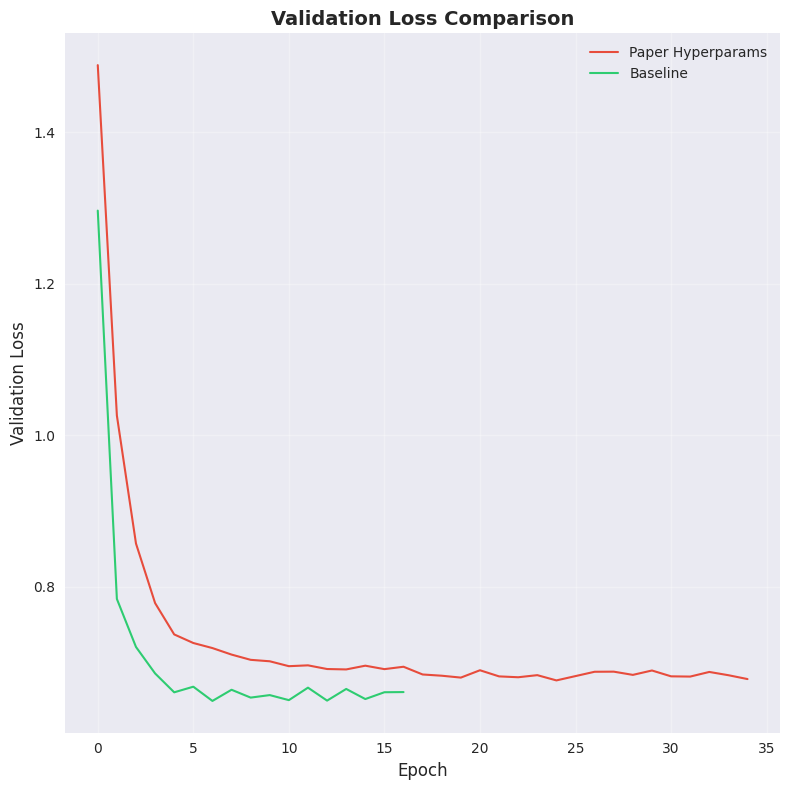

Saved to: /scratch/zt1/project/msml612/user/jeffy22/MSML612_EnergyForecasting/results/jeffy22/supervised_val_loss_comparison.png


In [12]:
if loss_data:
    fig, ax = plt.subplots(figsize=(8, 8))
    
    colors = {'Baseline': '#2ecc71', 'Paper Hyperparams': '#e74c3c'}
    
    for name, df in loss_data.items():
        if 'valid_loss' in df.columns:
            ax.plot(df['valid_loss'], label=name, color=colors.get(name, '#95a5a6'), linewidth=1.5)
    
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Validation Loss', fontsize=12)
    ax.set_title('Validation Loss Comparison', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'supervised_val_loss_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved to: {RESULTS_DIR / 'supervised_val_loss_comparison.png'}")

In [15]:
# Save results to CSV
results_table.to_csv(RESULTS_DIR / 'supervised_final_results.csv', index=False)

# Create summary DataFrame
summary_data = []
if baseline_avg:
    summary_data.append({'Experiment': 'Baseline (d_model=128)', 'MSE': baseline_avg, 'MSE_std': baseline_std, 'MAE': baseline_mae_avg, 'Num_Runs': len(baseline_df)})
if paper_avg:
    summary_data.append({'Experiment': 'Paper Hyperparams (d_model=16)', 'MSE': paper_avg, 'MSE_std': paper_std, 'MAE': paper_mae_avg, 'Num_Runs': len(paper_df)})

if summary_data:
    df_summary = pd.DataFrame(summary_data)
    df_summary.to_csv(RESULTS_DIR / 'supervised_summary.csv', index=False)
    print(f"Saved to: {RESULTS_DIR / 'supervised_summary.csv'}")

print("SUPERVISED VISUALIZATIONS COMPLETE!")
print("\nGenerated files:")
print(f"  {RESULTS_DIR / 'supervised_model_comparison.png'}")
print(f"  {RESULTS_DIR / 'supervised_our_results.png'}")
print(f"  {RESULTS_DIR / 'supervised_loss_curves.png'}")
print(f"  {RESULTS_DIR / 'supervised_val_loss_comparison.png'}")
print(f"  {RESULTS_DIR / 'supervised_final_results.csv'}")
print(f"  {RESULTS_DIR / 'supervised_summary.csv'}")

Saved to: /scratch/zt1/project/msml612/user/jeffy22/MSML612_EnergyForecasting/results/jeffy22/supervised_summary.csv
SUPERVISED VISUALIZATIONS COMPLETE!

Generated files:
  /scratch/zt1/project/msml612/user/jeffy22/MSML612_EnergyForecasting/results/jeffy22/supervised_model_comparison.png
  /scratch/zt1/project/msml612/user/jeffy22/MSML612_EnergyForecasting/results/jeffy22/supervised_our_results.png
  /scratch/zt1/project/msml612/user/jeffy22/MSML612_EnergyForecasting/results/jeffy22/supervised_loss_curves.png
  /scratch/zt1/project/msml612/user/jeffy22/MSML612_EnergyForecasting/results/jeffy22/supervised_val_loss_comparison.png
  /scratch/zt1/project/msml612/user/jeffy22/MSML612_EnergyForecasting/results/jeffy22/supervised_final_results.csv
  /scratch/zt1/project/msml612/user/jeffy22/MSML612_EnergyForecasting/results/jeffy22/supervised_summary.csv
